# Post-processing

Scan seeded experiment runs, cache metrics, and generate paper figures.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "post_processing" else NOTEBOOK_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from post_processing.plot_utils import (
    build_agent_comparisons,
    build_inferer_comparisons,
    inferer_comparison_agents,
    load_results_cache,
    plot_agents_mean_std,
    safe_filename,
    scan_experiments,
    write_results_cache,
)

plt.rcParams.update({"figure.dpi": 120})

In [2]:
# Configuration
RUNS_ROOT = REPO_ROOT / "runs" / "seeded"
POST_PROCESSING_DIR = REPO_ROOT / "post_processing"
CACHE_PATH = POST_PROCESSING_DIR / "experiment_results.json"
FIGURES_DIR = POST_PROCESSING_DIR / "figures"
FIGURE_FORMAT = "pdf"  # use "pdf" or "png"

# Empty allowlist means every folder under RUNS_ROOT is eligible.
ALLOW_FOLDERS: set[str] = set()
BLOCK_FOLDERS: set[str] = set()

# Toggle this to False after the cache exists and you only want to replot.
REBUILD_CACHE = True

if FIGURE_FORMAT not in {"pdf", "png"}:
    raise ValueError("FIGURE_FORMAT must be either 'pdf' or 'png'.")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
if REBUILD_CACHE:
    experiments = scan_experiments(
        RUNS_ROOT,
        allow_folders=ALLOW_FOLDERS,
        block_folders=BLOCK_FOLDERS,
        skip_invalidated=True,
        skip_empty=True,
    )
    write_results_cache(experiments, CACHE_PATH)
else:
    experiments = load_results_cache(CACHE_PATH)

len(experiments), CACHE_PATH

(188,
 PosixPath('/Users/zerquiolin/Desktop/Studies/Masters/TheCausalityGame/package/post_processing/experiment_results.json'))

In [4]:
by_mission_inferer_agent = build_agent_comparisons(experiments)
by_mission_agent_inferer = build_inferer_comparisons(experiments)

sorted(
    (mission, inferer, len(agents))
    for mission, inferers in by_mission_inferer_agent.items()
    for inferer, agents in inferers.items()
)

[('graph_discovery', 'dag_discovery', 7),
 ('graph_discovery', 'lingam', 7),
 ('graph_discovery', 'notears', 7),
 ('graph_discovery', 'pc', 7),
 ('scm_discovery', 'scm_discovery', 7),
 ('symbolic_scm_discovery', 'sparse_symbolic_scm', 1),
 ('treatment_effect', 'honest_causal_tree', 7),
 ('treatment_effect', 'outcome_regression', 7),
 ('treatment_effect', 'transformed_outcome', 7)]

## Agent comparisons within each mission/inferer

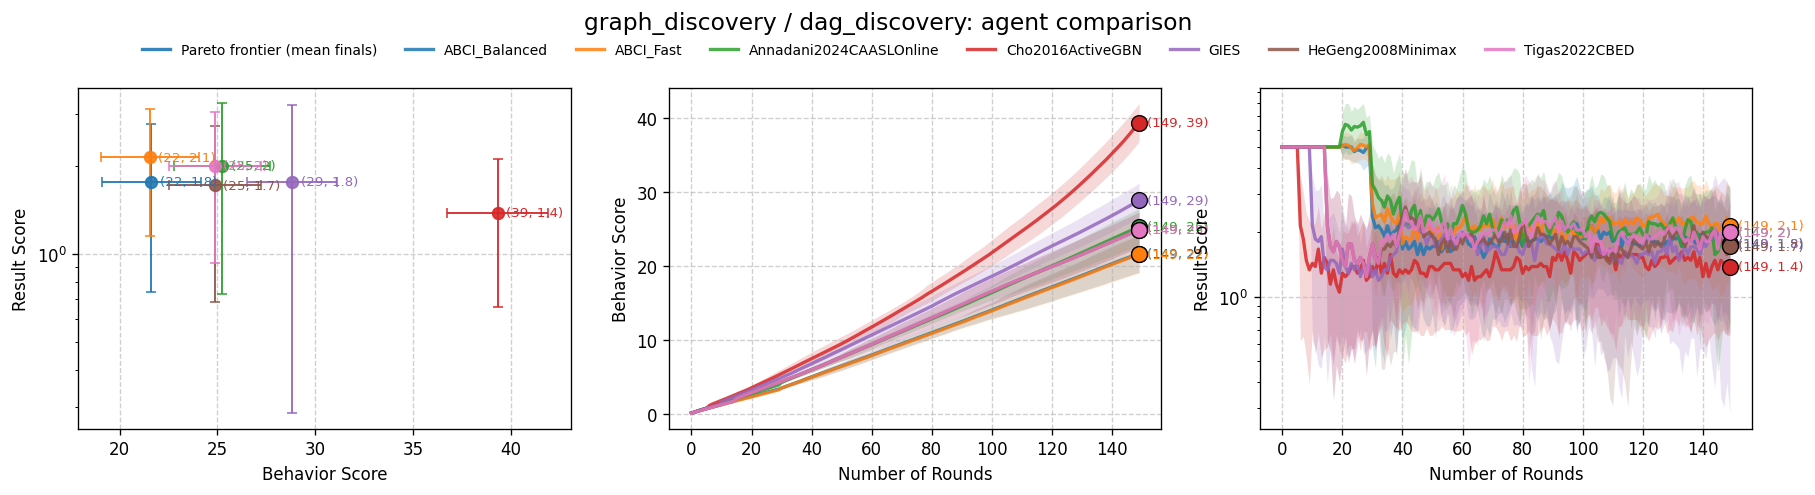

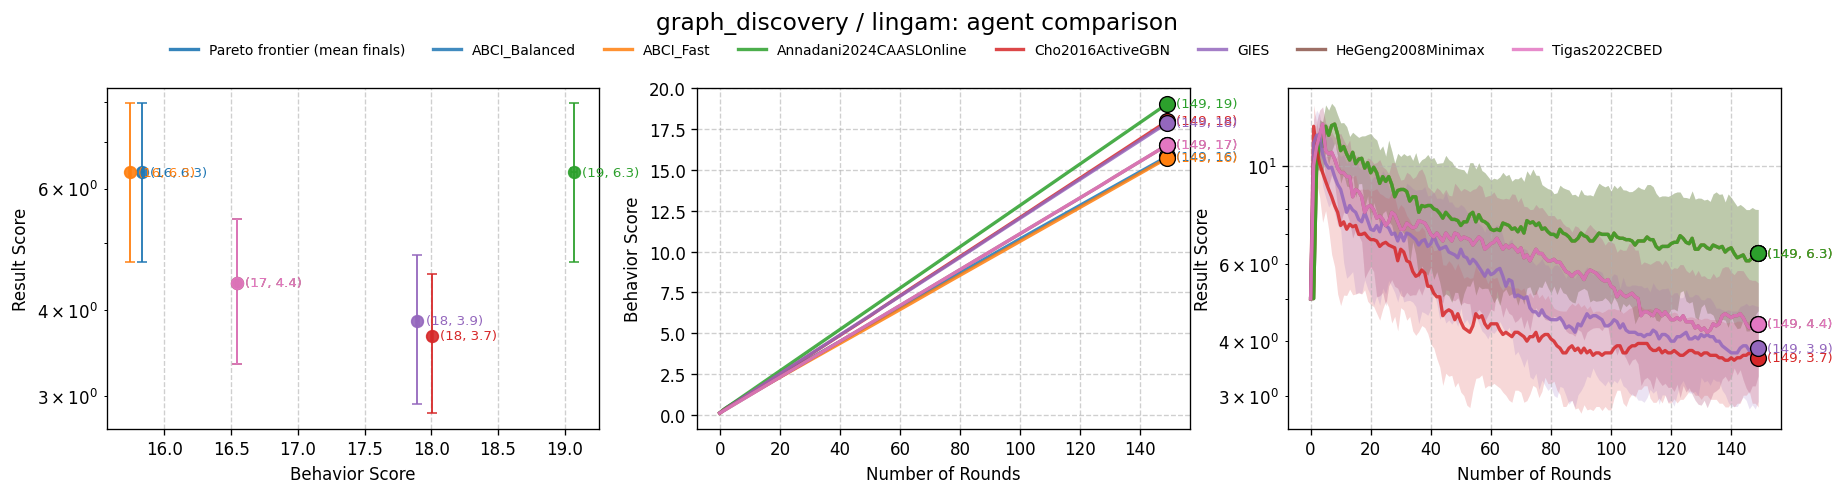

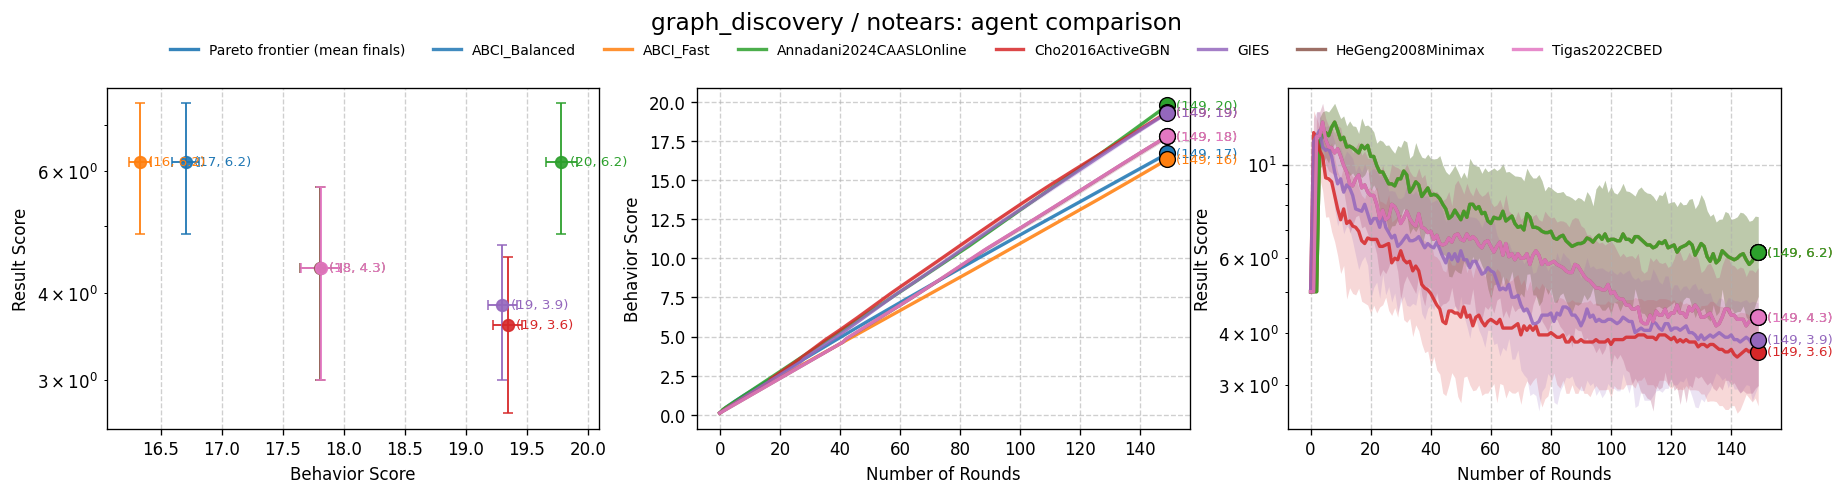

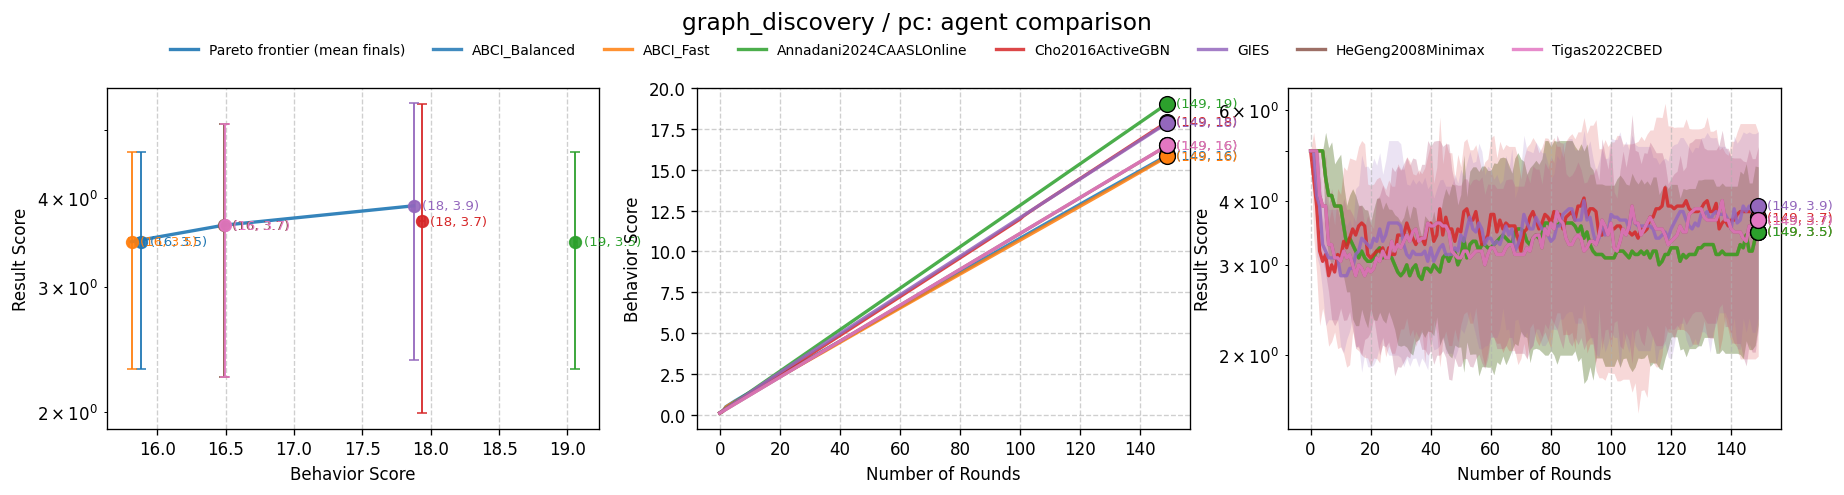

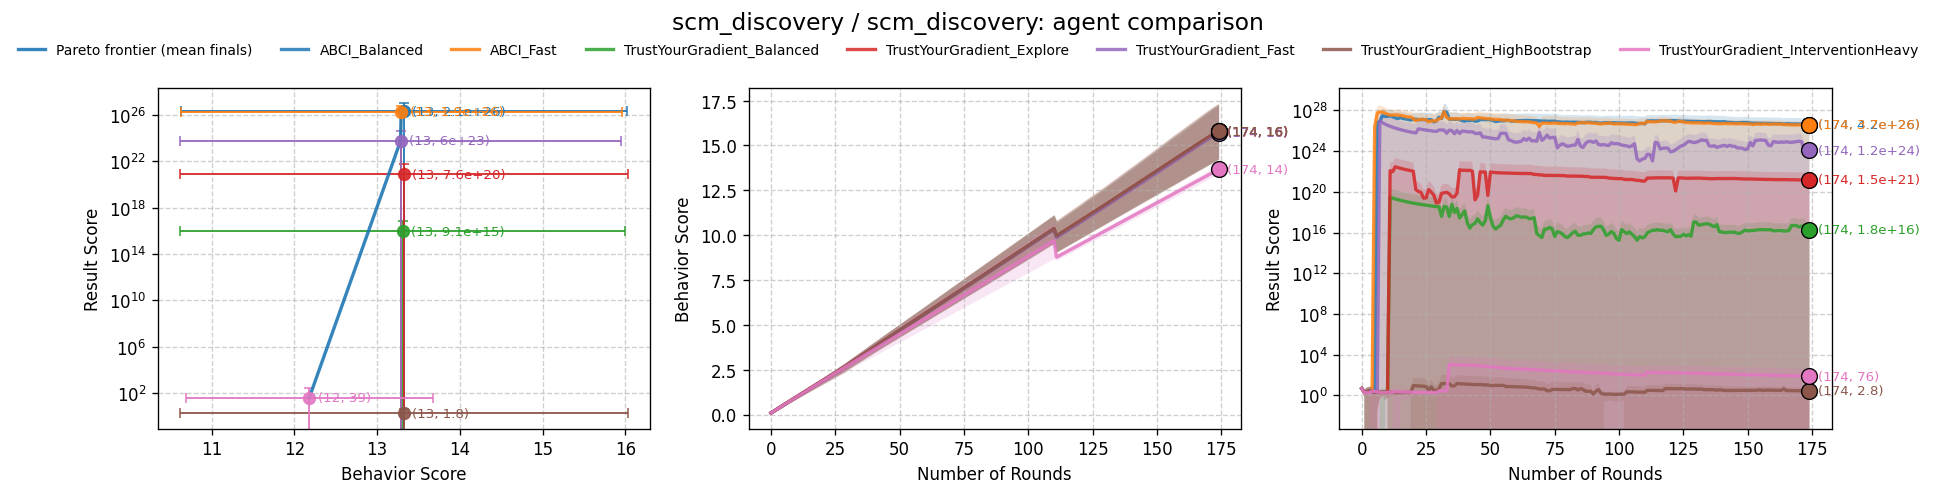

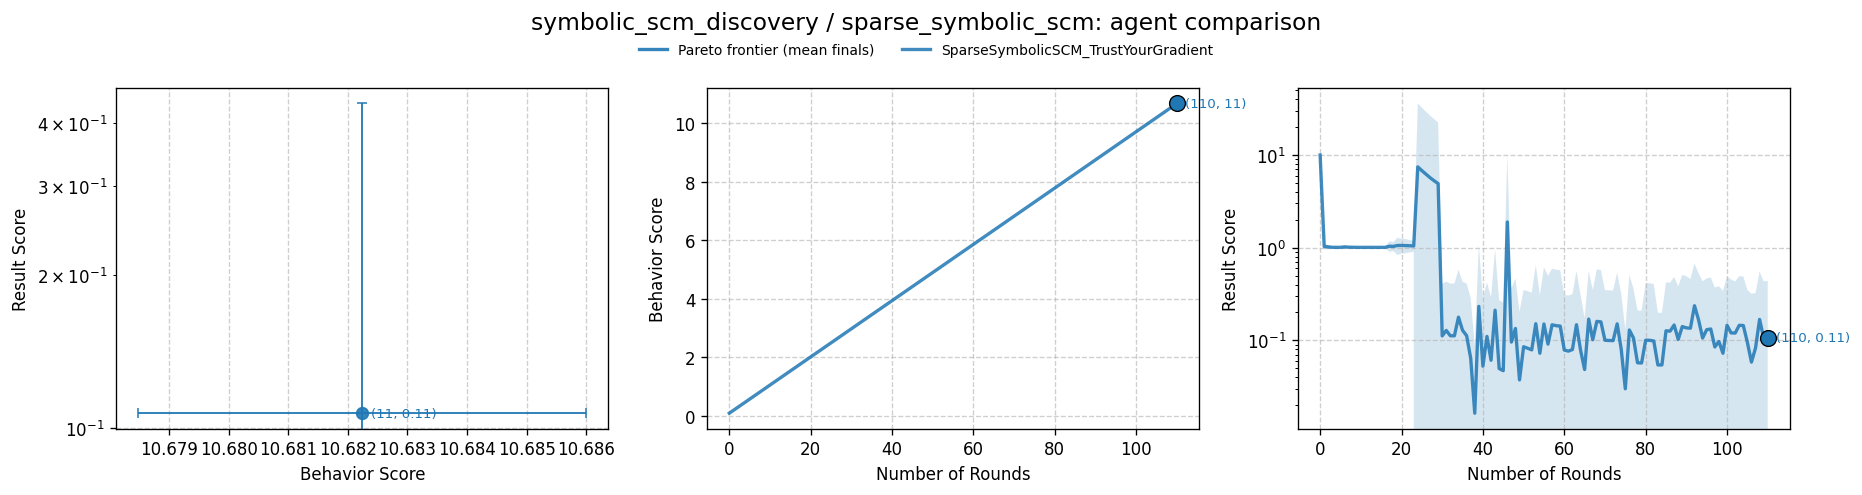

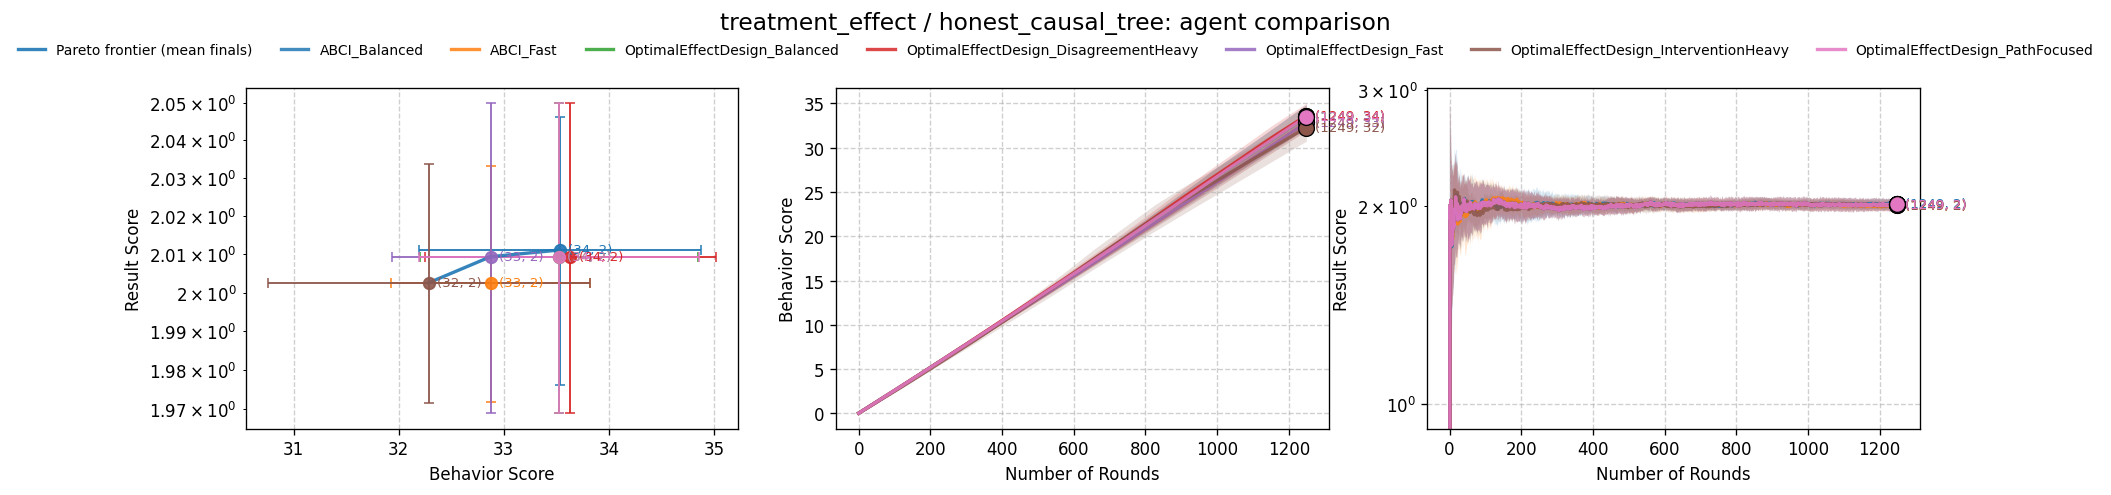

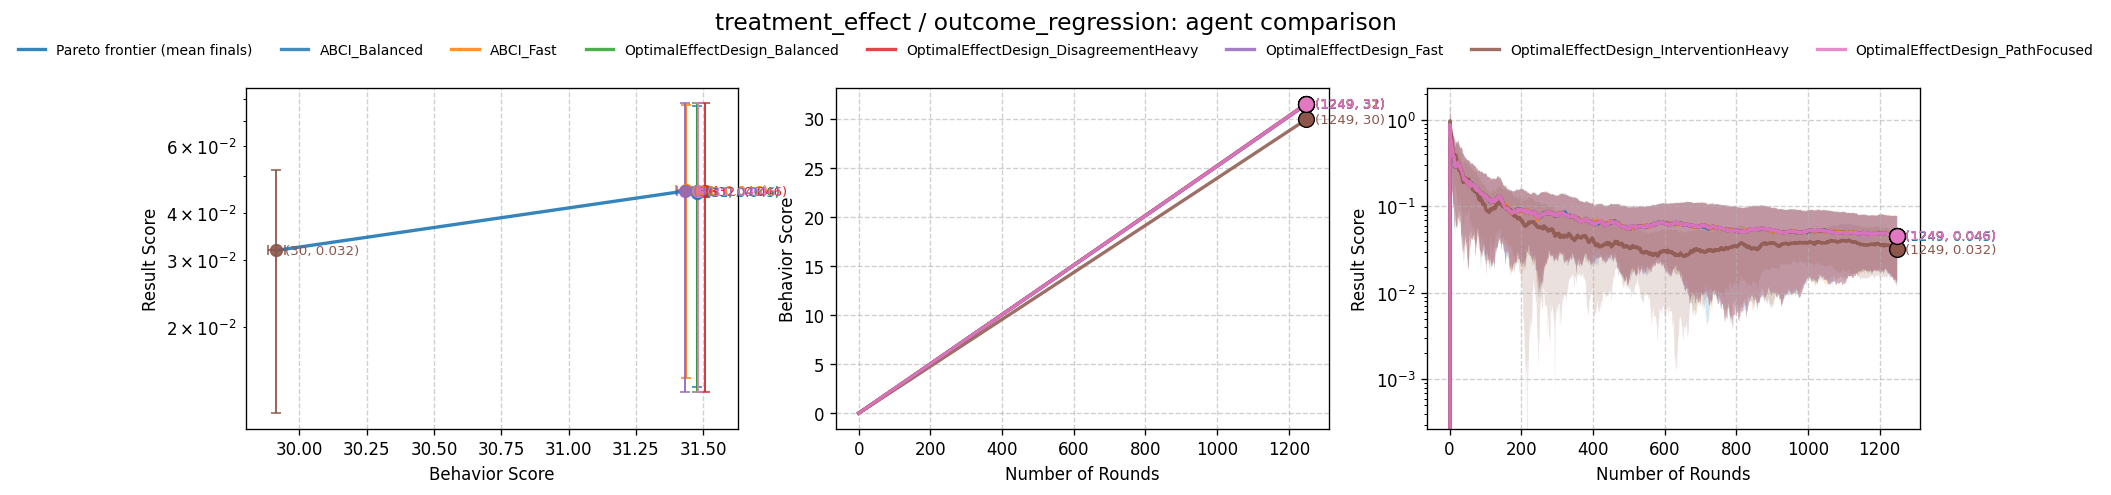

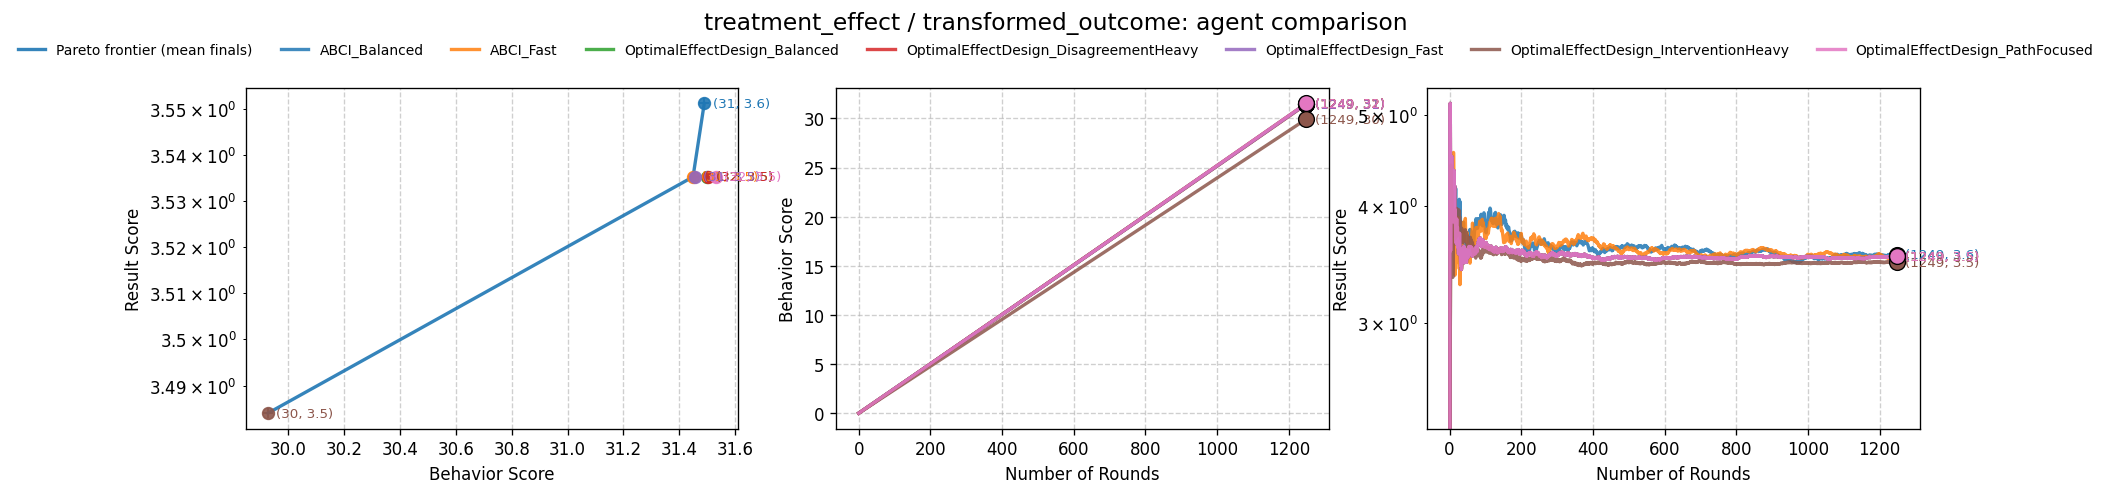

[PosixPath('/Users/zerquiolin/Desktop/Studies/Masters/TheCausalityGame/package/post_processing/figures/agents__graph_discovery__dag_discovery.png'),
 PosixPath('/Users/zerquiolin/Desktop/Studies/Masters/TheCausalityGame/package/post_processing/figures/agents__graph_discovery__lingam.png'),
 PosixPath('/Users/zerquiolin/Desktop/Studies/Masters/TheCausalityGame/package/post_processing/figures/agents__graph_discovery__notears.png'),
 PosixPath('/Users/zerquiolin/Desktop/Studies/Masters/TheCausalityGame/package/post_processing/figures/agents__graph_discovery__pc.png'),
 PosixPath('/Users/zerquiolin/Desktop/Studies/Masters/TheCausalityGame/package/post_processing/figures/agents__scm_discovery__scm_discovery.png'),
 PosixPath('/Users/zerquiolin/Desktop/Studies/Masters/TheCausalityGame/package/post_processing/figures/agents__symbolic_scm_discovery__sparse_symbolic_scm.png'),
 PosixPath('/Users/zerquiolin/Desktop/Studies/Masters/TheCausalityGame/package/post_processing/figures/agents__treatmen

In [ ]:
agent_comparison_figures = []

for mission, inferers in sorted(by_mission_inferer_agent.items()):
    for inferer, agents in sorted(inferers.items()):
        if not agents:
            continue
        title = f"{mission} / {inferer}: agent comparison"
        fig, axes = plot_agents_mean_std(agents, title=title)
        output_path = (
            FIGURES_DIR / f"agents__{safe_filename(mission)}__{safe_filename(inferer)}.{FIGURE_FORMAT}"
        )
        fig.savefig(output_path, bbox_inches="tight", format=FIGURE_FORMAT)
        agent_comparison_figures.append(output_path)
        plt.show()
        plt.close(fig)

agent_comparison_figures

## Same agent across inferers within each mission

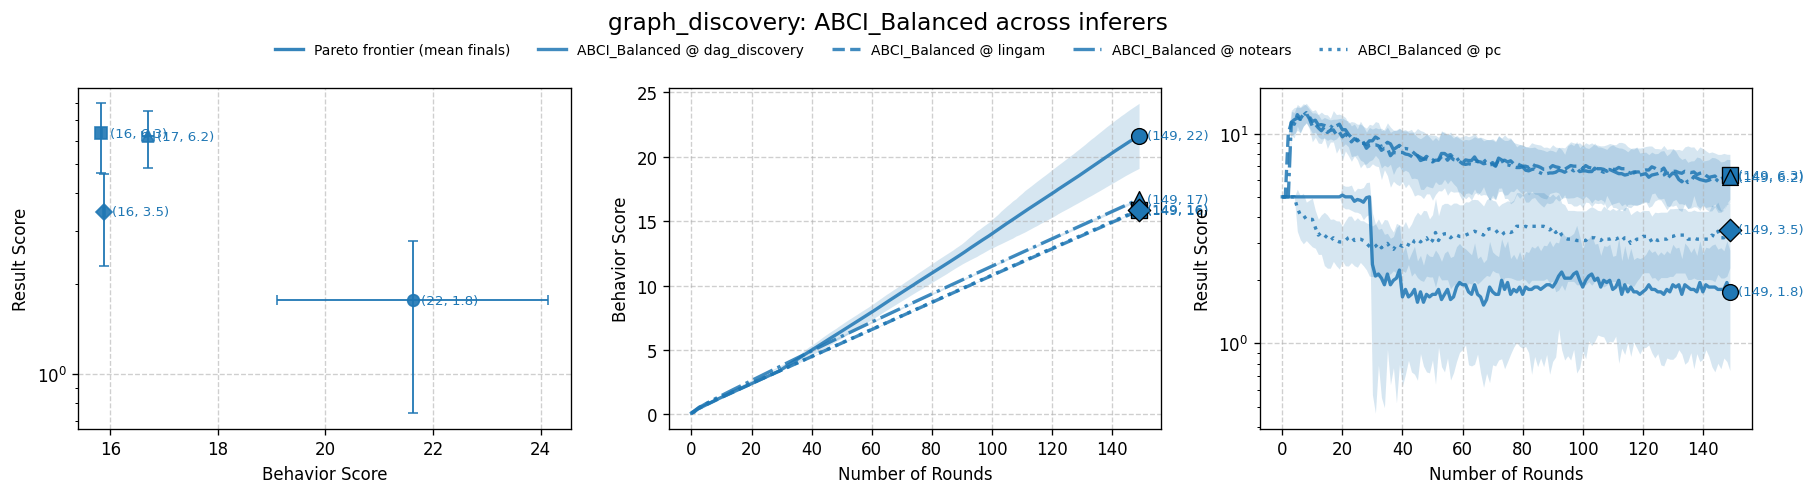

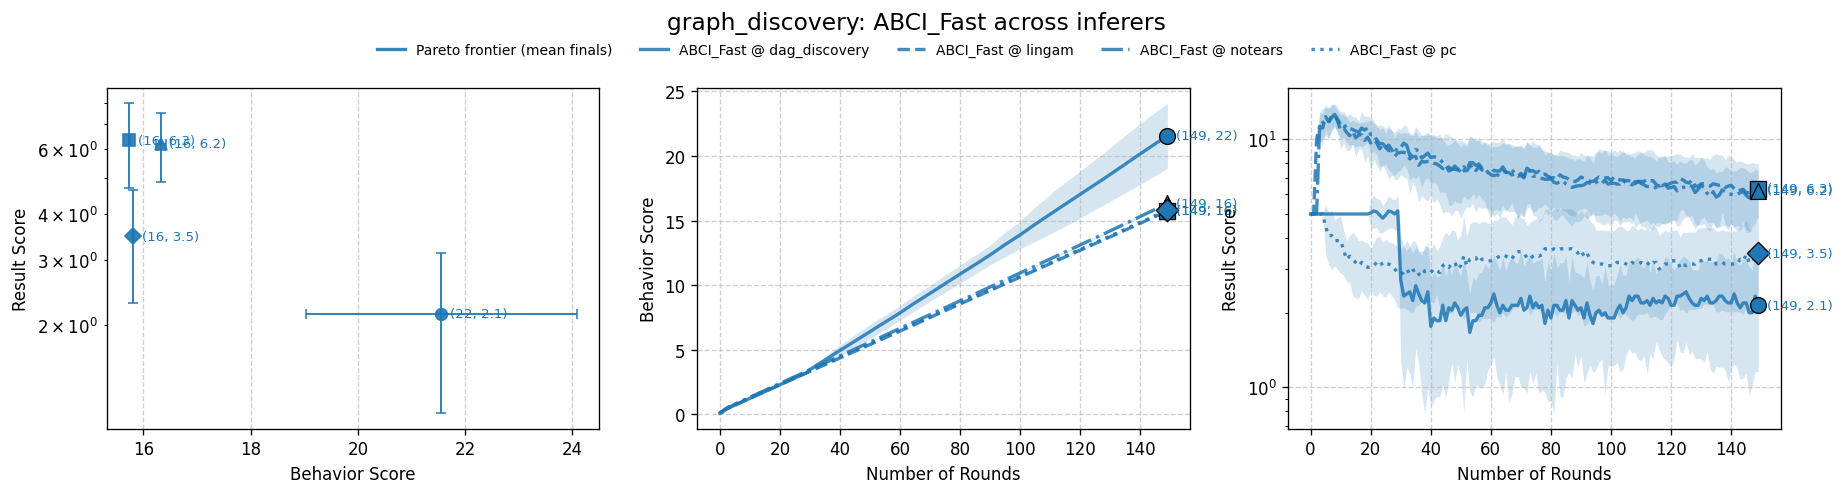

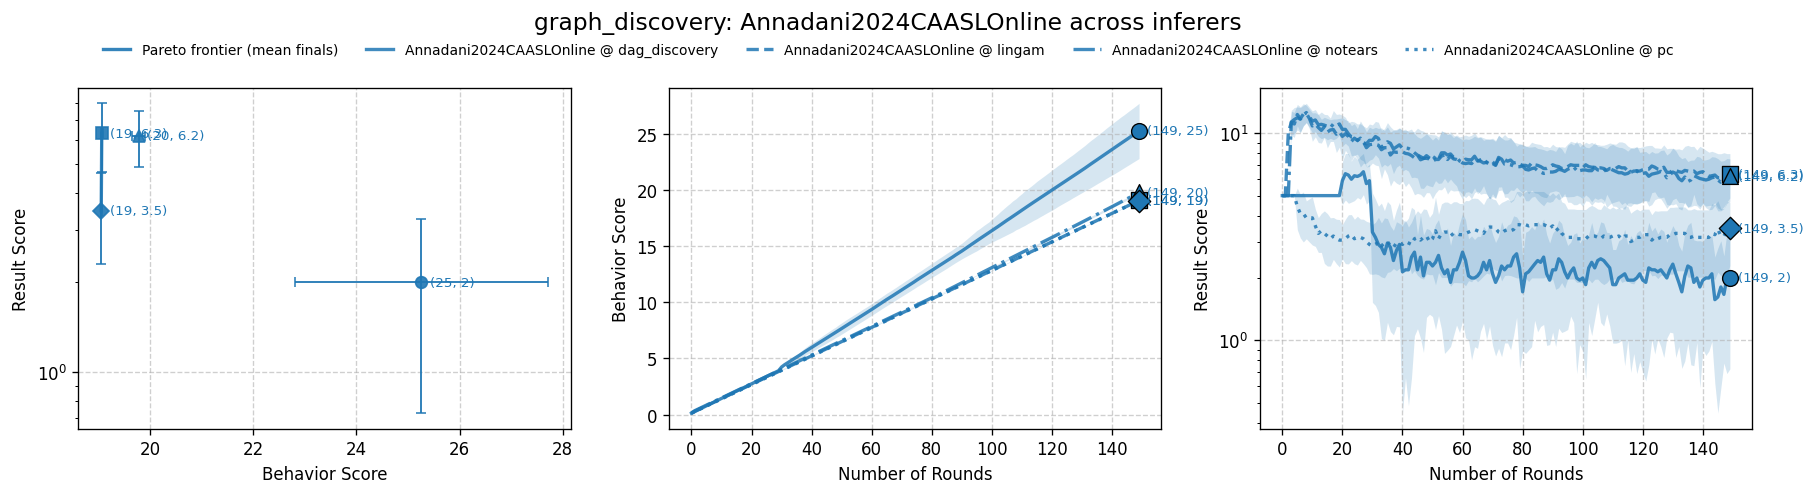

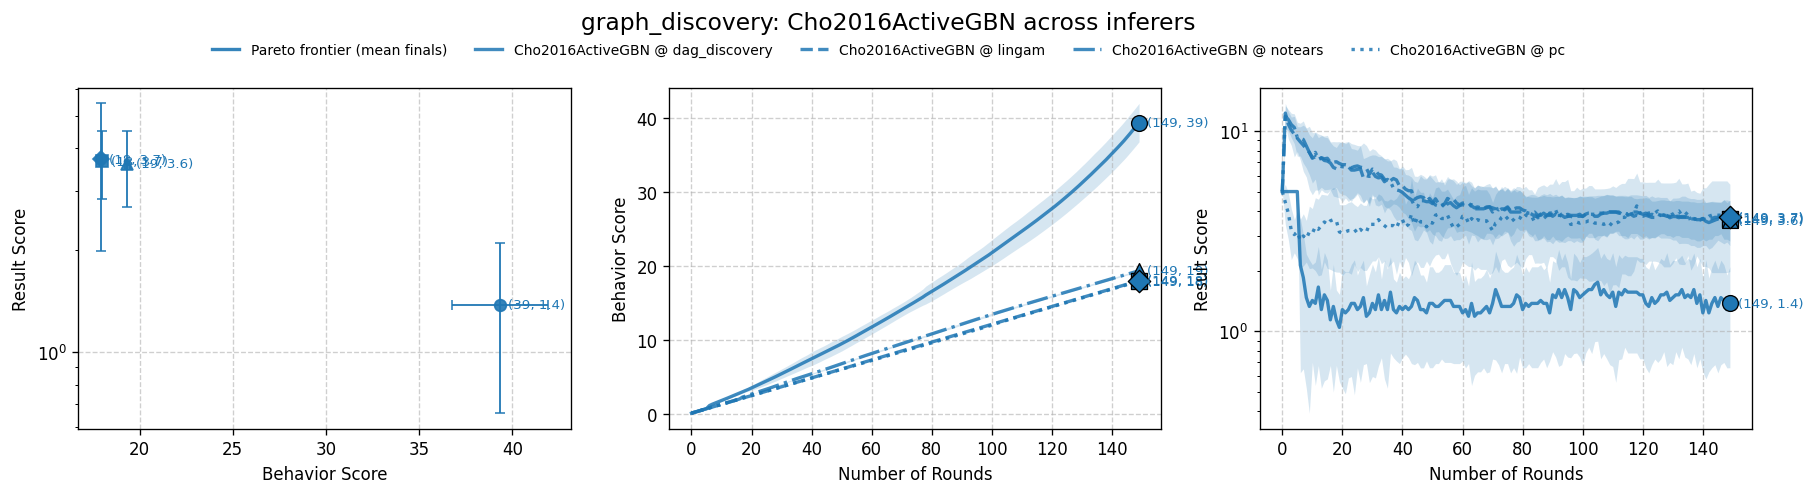

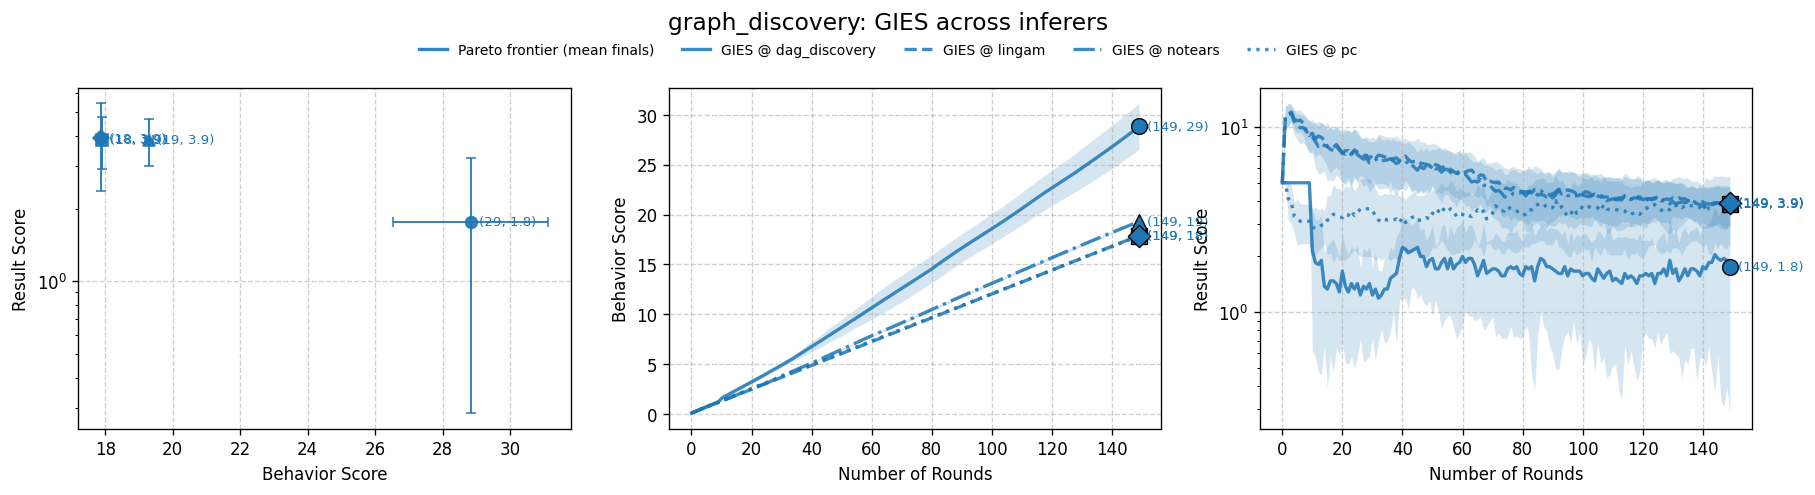

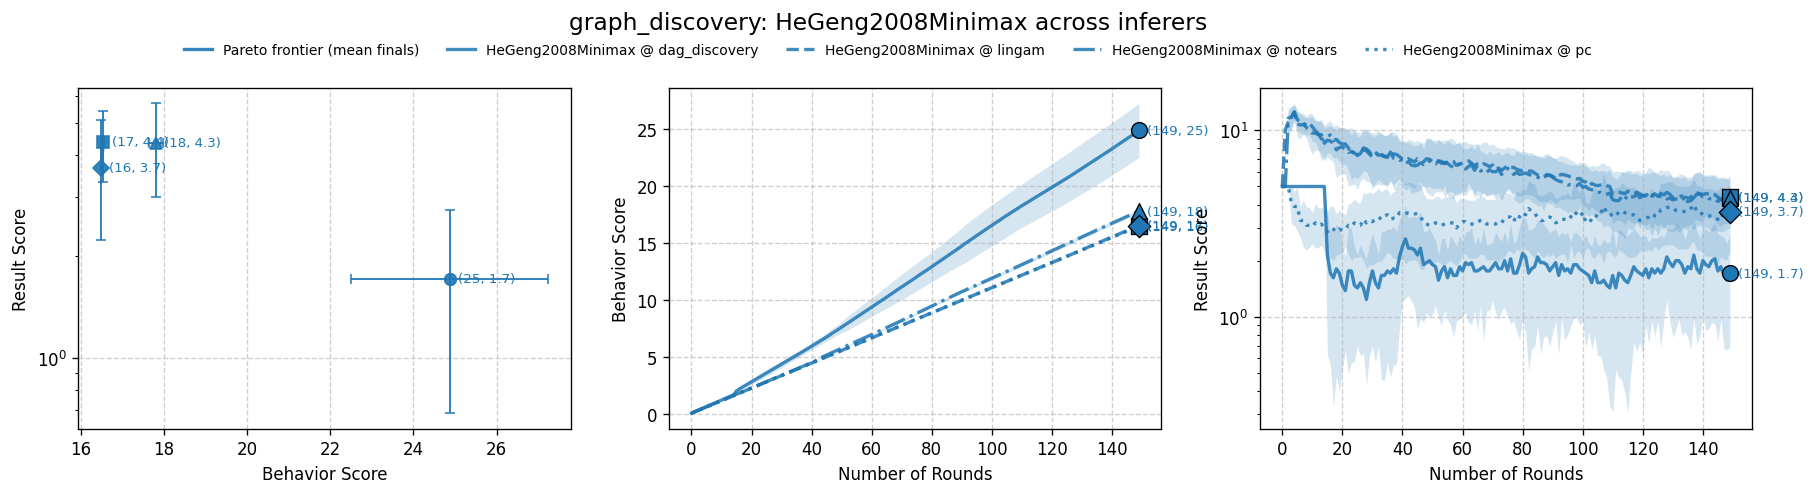

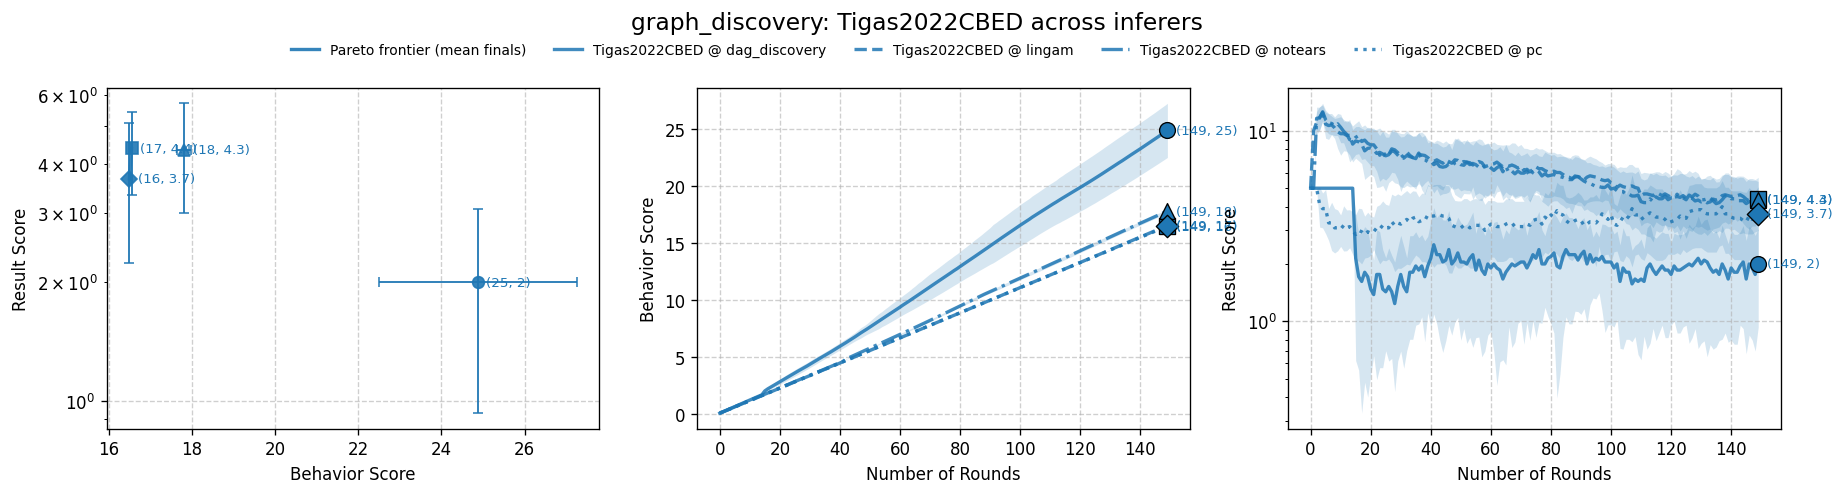

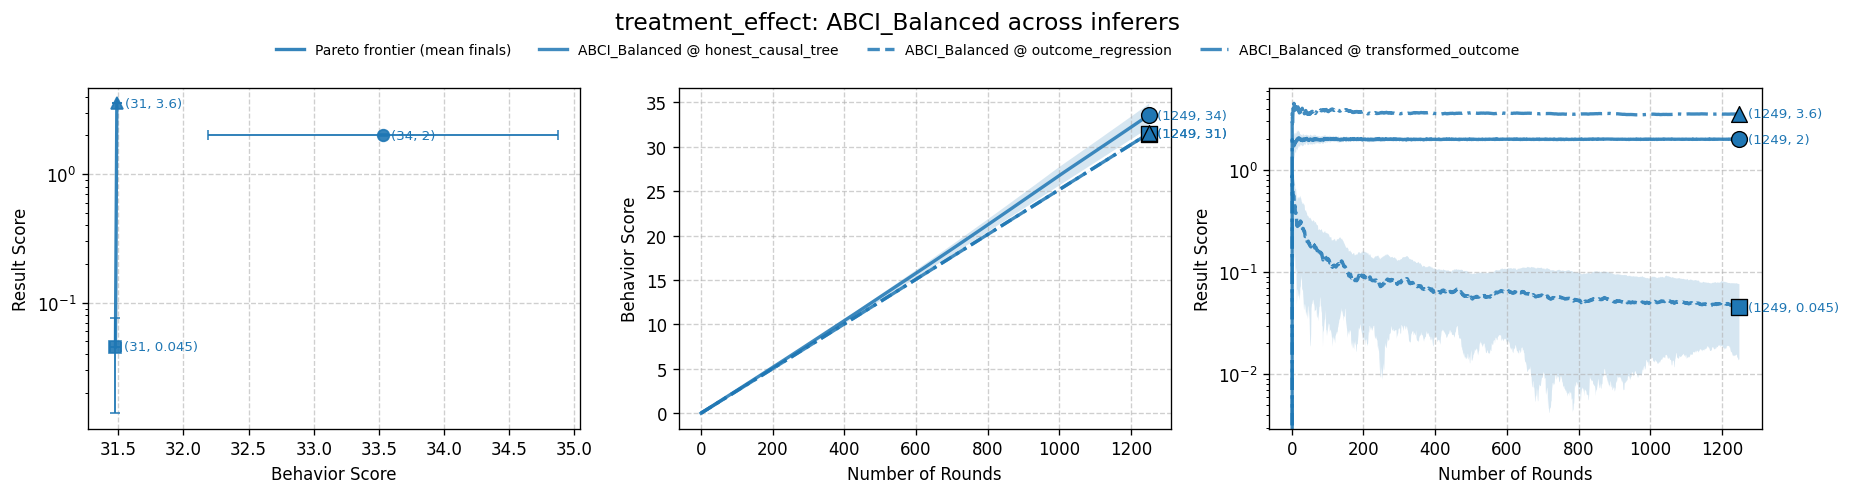

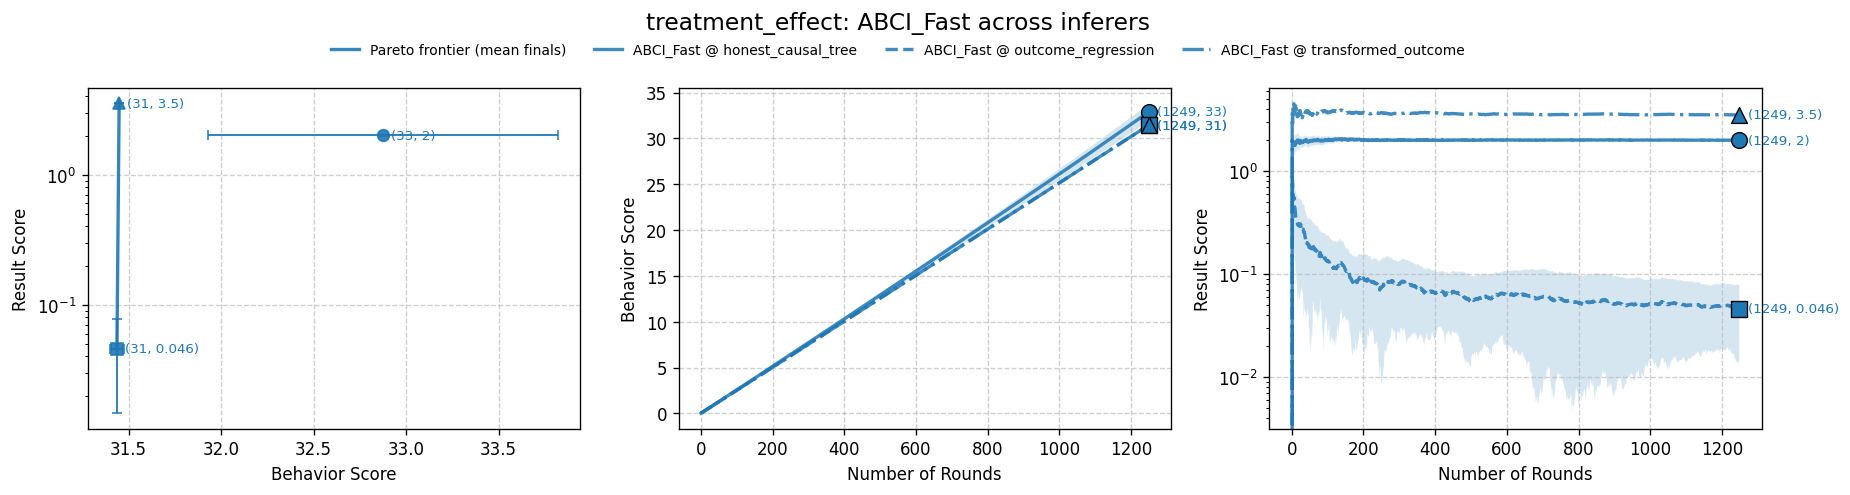

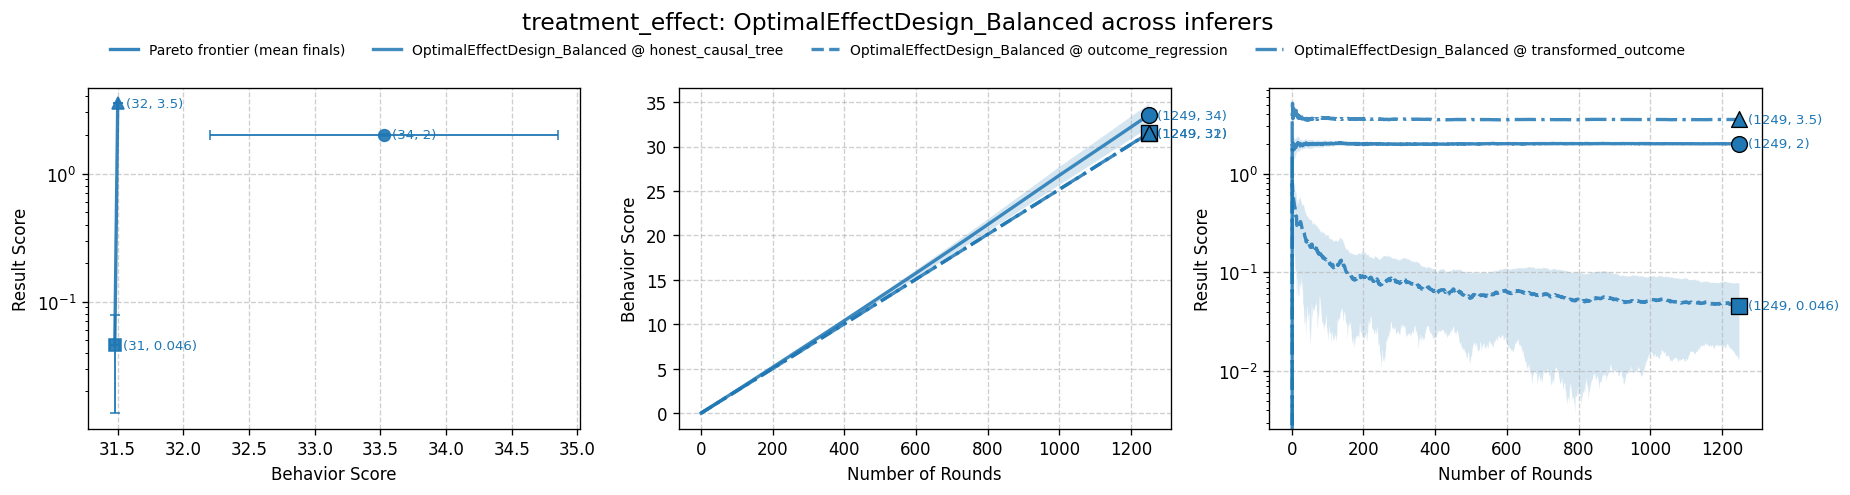

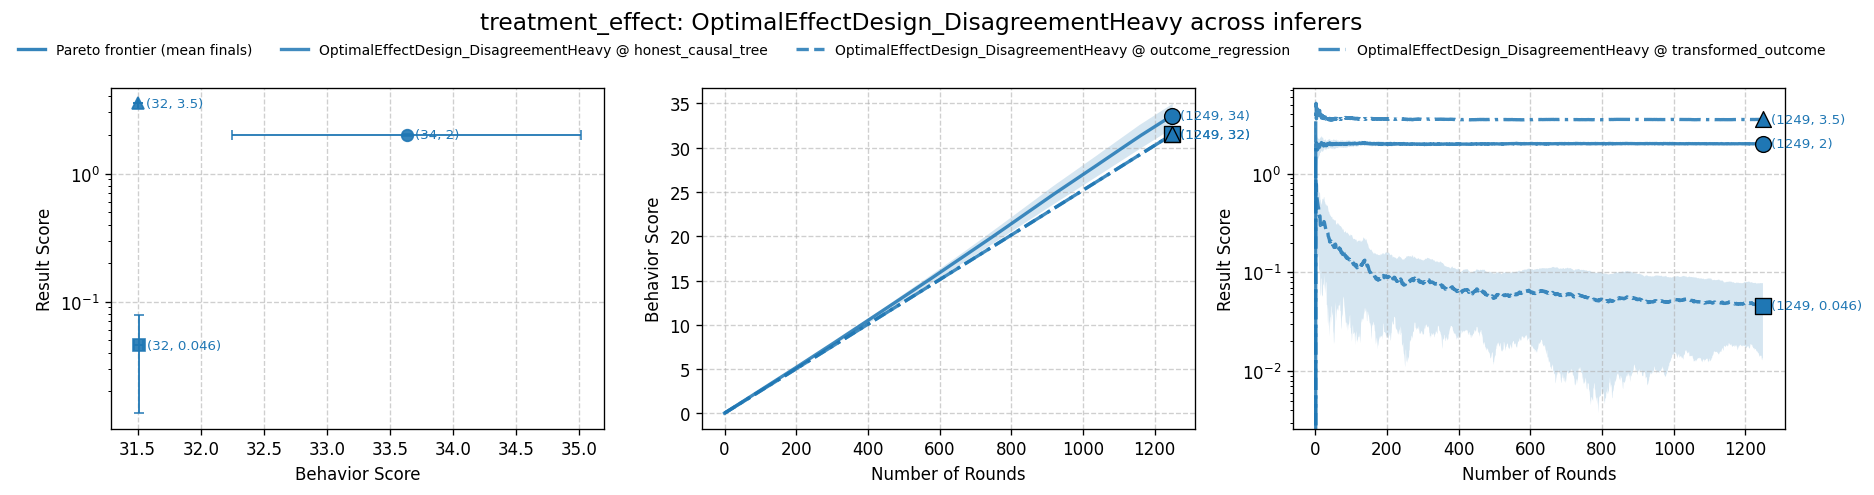

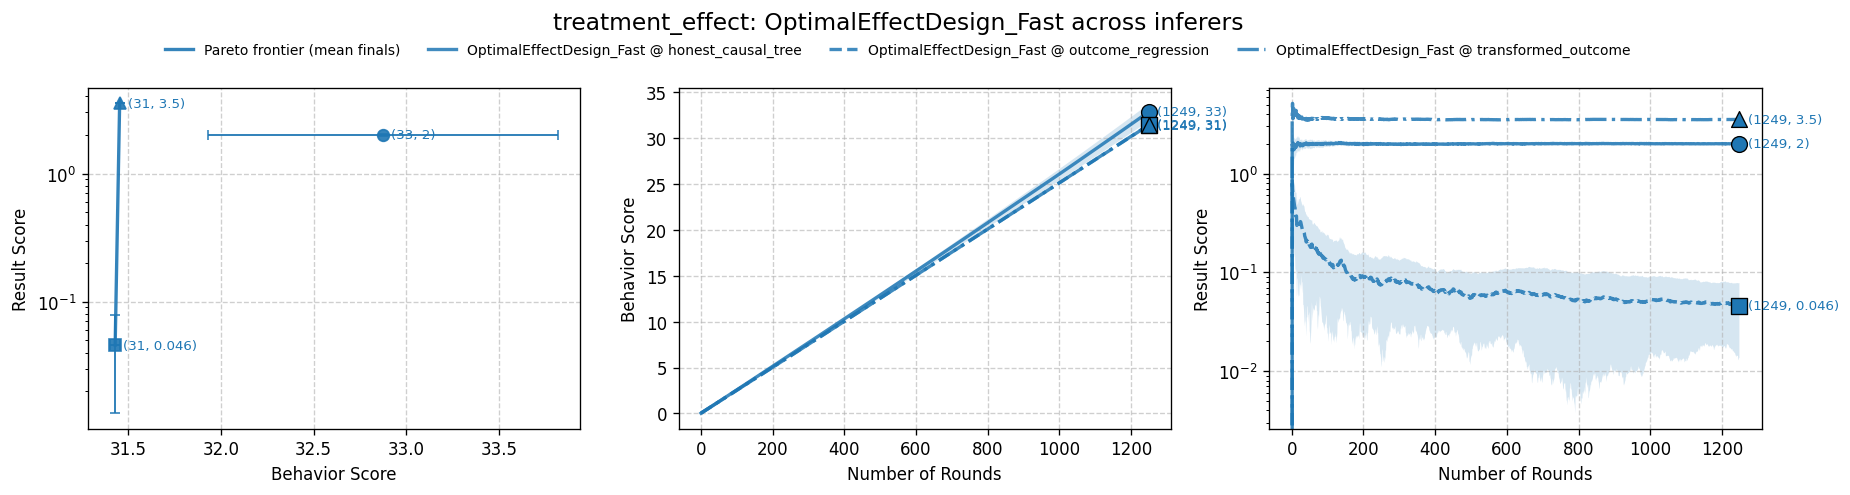

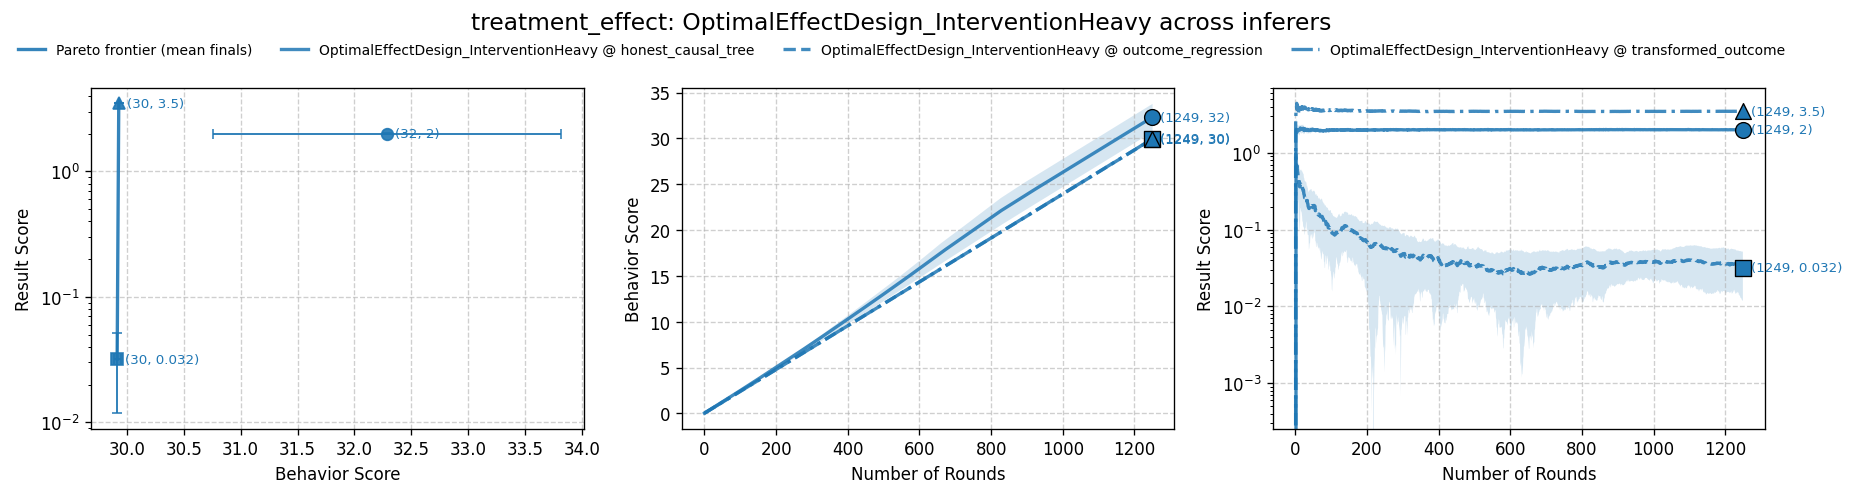

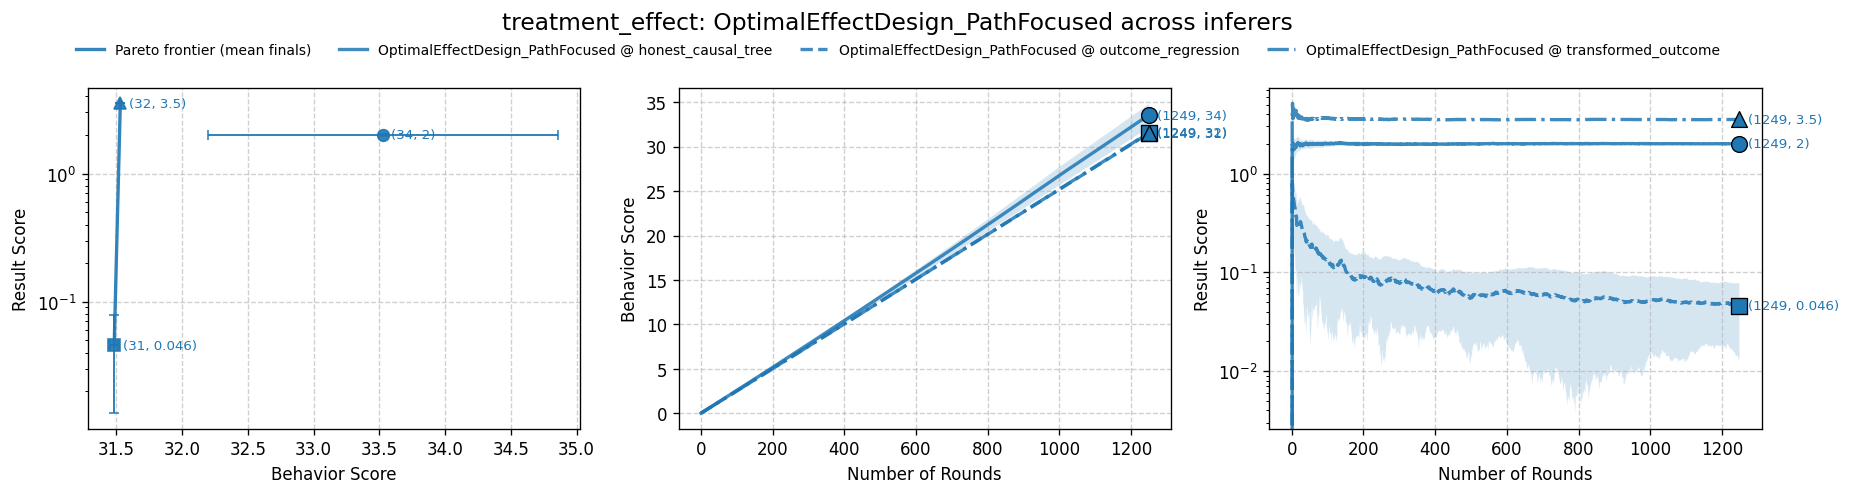

[PosixPath('/Users/zerquiolin/Desktop/Studies/Masters/TheCausalityGame/package/post_processing/figures/inferers__graph_discovery__ABCI_Balanced.png'),
 PosixPath('/Users/zerquiolin/Desktop/Studies/Masters/TheCausalityGame/package/post_processing/figures/inferers__graph_discovery__ABCI_Fast.png'),
 PosixPath('/Users/zerquiolin/Desktop/Studies/Masters/TheCausalityGame/package/post_processing/figures/inferers__graph_discovery__Annadani2024CAASLOnline.png'),
 PosixPath('/Users/zerquiolin/Desktop/Studies/Masters/TheCausalityGame/package/post_processing/figures/inferers__graph_discovery__Cho2016ActiveGBN.png'),
 PosixPath('/Users/zerquiolin/Desktop/Studies/Masters/TheCausalityGame/package/post_processing/figures/inferers__graph_discovery__GIES.png'),
 PosixPath('/Users/zerquiolin/Desktop/Studies/Masters/TheCausalityGame/package/post_processing/figures/inferers__graph_discovery__HeGeng2008Minimax.png'),
 PosixPath('/Users/zerquiolin/Desktop/Studies/Masters/TheCausalityGame/package/post_proces

In [ ]:
inferer_comparison_figures = []

for mission, agents in sorted(by_mission_agent_inferer.items()):
    for agent, inferers in sorted(agents.items()):
        if len(inferers) < 2:
            continue
        plot_data = inferer_comparison_agents(by_mission_agent_inferer, mission, agent)
        title = f"{mission}: {agent} across inferers"
        fig, axes = plot_agents_mean_std(plot_data, title=title)
        output_path = (
            FIGURES_DIR / f"inferers__{safe_filename(mission)}__{safe_filename(agent)}.{FIGURE_FORMAT}"
        )
        fig.savefig(output_path, bbox_inches="tight", format=FIGURE_FORMAT)
        inferer_comparison_figures.append(output_path)
        plt.show()
        plt.close(fig)

inferer_comparison_figures